In [6]:
from vectors import *

def matrix_multiply(a, b):
    return tuple(tuple(dot(row, col) for col in zip(*b)) for row in a)    

def multiply_matrix_vector(matrix, vector):
    return linear_combination(vector, *zip(*matrix))

In [12]:
a = ((1, 1, 0), (1, 0, 1), (1, -1, 1))
b = ((0, 2, 1), (0, 1, 0), (1, 0, -1))
print(matrix_multiply(a, b))

((0, 3, 1), (1, 2, 0), (1, 1, 0))


In [ ]:
from teapot import load_triangles
from draw_model import draw_model
from math import sin, cos


def get_rotation_matrix(t):
    seconds = t / 1000
    return (
        (cos(seconds), 0, -sin(seconds)),
        (0, 1, 0),
        (sin(seconds), 0, cos(seconds)),
    )


draw_model(load_triangles(), get_matrix=get_rotation_matrix)

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.7)


SystemExit: 

/Users/bruce/Workspace/Projects/mine/playground/python/math-for-programmers/.venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


: 

In [4]:
c = ((-1, -1, 0), (-2, 1, 2), (1, 0, -1))
d = ((1,), (1,), (1,))
matrix_multiply(c, d)

((-2,), (1,), (0,))

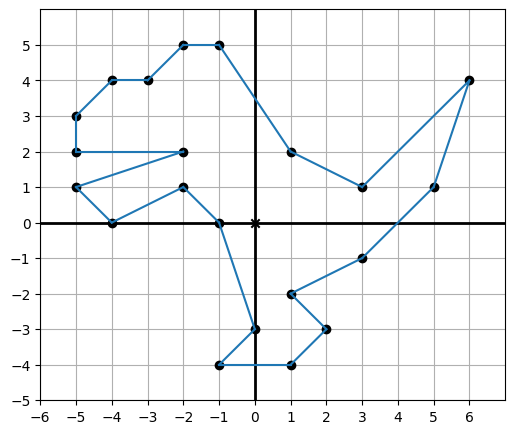

In [3]:
from vector_drawing import *

dino_vectors = [(6,4), (3,1), (1,2), (-1,5), (-2,5), (-3,4), (-4,4),
    (-5,3), (-5,2), (-2,2), (-5,1), (-4,0), (-2,1), (-1,0), (0,-3),
    (-1,-4), (1,-4), (2,-3), (1,-2), (3,-1), (5,1)
]
 
draw(
    Points(*dino_vectors),
    Polygon(*dino_vectors)
)

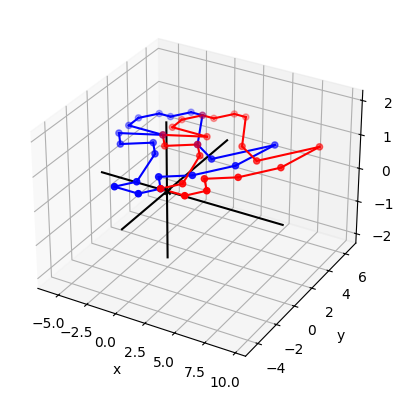

In [ ]:
from draw3d import *


def polygon_segments_3d(points, color="blue"):
    count = len(points)
    return [
        Segment3D(points[i], points[(i + 1) % count], color=color) for i in range(count)
    ]


dino_3d_vectors = [(x, y, 1) for x, y in dino_vectors]

magic_matrix = ((1, 0, 3), (0, 1, 1), (0, 0, 1))

translated = [multiply_matrix_vector(magic_matrix, point) for point in dino_3d_vectors]

draw3d(
    Points3D(*dino_3d_vectors, color="blue"), *polygon_segments_3d(dino_3d_vectors),
    Points3D(*translated, color="red"), *polygon_segments_3d(translated, color="red")
)

In [15]:
def translate_3d(translation):
    def new_function(target):
        a,b,c = translation
        x,y,z = target
        matrix = ((1, 0, 0, a), (0, 1, 0, b), (0, 0, 1, c), (0, 0, 0, 1))  # 2
        vector = (x, y, z, 1)
        x_out, y_out, z_out, _ = multiply_matrix_vector(matrix, vector)  # 3
        return (x_out, y_out, z_out)

    return new_function

In [14]:
!python matrix_translate_teapot.py

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.7)


In [17]:
!python animate_teapot.py

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.7)


In [20]:
!python matrix_transform_teapot.py

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.7)
